# Part I: Preprocessing

## Basic Setups

In [1]:
import os
import sys
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


warnings.filterwarnings("ignore")

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

In [3]:
import importlib
import utils.data_generator as dg
importlib.reload(dg)

from utils.data_generator import (
    check_missing_value,
    filling_missing_value_with_mean,
    filling_missing_value_with_median,
    correct_outliers,
)

In [ ]:
DATA_DIR="../data"

## Load and Clean Data

In [5]:
df_sales_2016=pd.read_csv(os.path.join(DATA_DIR, "2016_sales.csv"))
df_sales_2017=pd.read_csv(os.path.join(DATA_DIR, "2017_sales.csv"))
df_weather=pd.read_csv(os.path.join(DATA_DIR, "weather_data.csv"))

In [6]:
# Combine sales data
df_sales=pd.concat([df_sales_2016, df_sales_2017], ignore_index=True)

# Convert date columns to datetime
df_sales["date"] = pd.to_datetime(df_sales["date"])
df_weather["date"] = pd.to_datetime(df_weather["date"])

## Handling missing values

### Checking missing values

In [7]:
check_missing_value(df_sales)

,count,percentage
date,0,0.0
province,0,0.0
store_id,0,0.0
store_name,0,0.0
category,0,0.0
item_id,0,0.0
item_name,0,0.0
sales,2009,1.0


### Filling missing values with median

In [8]:
# Fill missing values with mean 
df_sales_filled=filling_missing_value_with_median(df_sales)

In [9]:
# Check missing values again after filling
check_missing_value(df_sales_filled)

,count,percentage
date,0,0.0
province,0,0.0
store_id,0,0.0
store_name,0,0.0
category,0,0.0
item_id,0,0.0
item_name,0,0.0
sales,0,0.0


## Checking and correcting outliers

In [10]:
df_sales_filled.head()

,date,province,store_id,store_name,category,item_id,item_name,sales
0,2016-01-01,Hanoi,1,Hoan Kiem Market,Staples,1,Rice,17.0
1,2016-01-01,Hanoi,1,Hoan Kiem Market,Staples,2,Noodles,10.0
2,2016-01-01,Hanoi,1,Hoan Kiem Market,Staples,3,Bread,6.0
3,2016-01-01,Hanoi,1,Hoan Kiem Market,Staples,4,Flour,8.0
4,2016-01-01,Hanoi,1,Hoan Kiem Market,Staples,5,Cooking Oil,8.0


### Data Validation

In [11]:
# Check if dupplicate rows exist
df_sales.duplicated().sum()

#   Invalid sales
df_sales[df_sales["sales"] < 0]

#  Date range
df_sales["date"].min(), df_sales["date"].max()

# Unique identifiers
df_sales["store_id"].nunique(), df_sales["item_id"].nunique()

(10, 35)

### Outlier checks on sales

In [12]:
df_sales_filled["sales"].describe()

count    201025.000000
mean         29.422967
std          26.246649
min           1.000000
25%          13.000000
50%          21.000000
75%          36.000000
max         561.000000
Name: sales, dtype: float64

The sales variable appears to be positively skewed.

### IQR and Outlier Rate

In [13]:
Q1=df_sales_filled["sales"].quantile(0.25)
Q3=df_sales_filled["sales"].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

In [14]:
outliers_iqr=df_sales_filled[(df_sales_filled["sales"]<lower)|(df_sales_filled["sales"]>upper)]
outlier_rate=len(outliers_iqr)/len(df_sales_filled)
print("Outlier Rate: {}%".format(np.round(outlier_rate*100,1)))
print("Number of Outliers: {}".format(outliers_iqr.shape[0]))

Outlier Rate: 6.9%
Number of Outliers: 13871


### Visualization using Hist, Boxplot and IQR

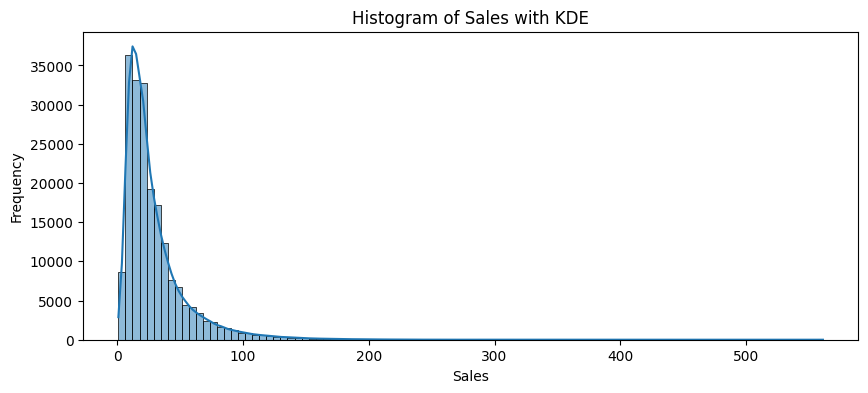

In [15]:
# plot the histogram
plt.figure(figsize=(10, 4))
sns.histplot(df_sales_filled["sales"], bins=100, kde=True)
plt.title("Histogram of Sales with KDE")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

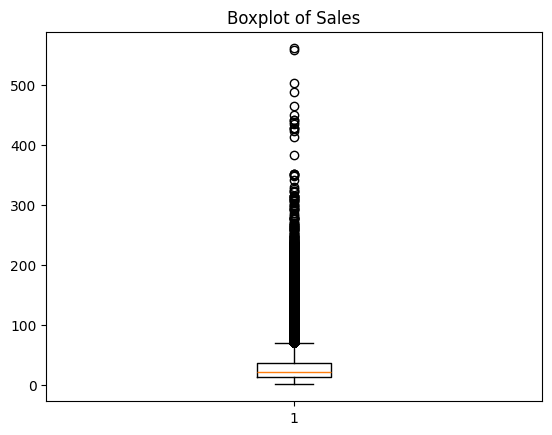

In [16]:
# Box plot
plt.boxplot(df_sales_filled["sales"].dropna())
plt.title("Boxplot of Sales")
plt.show()

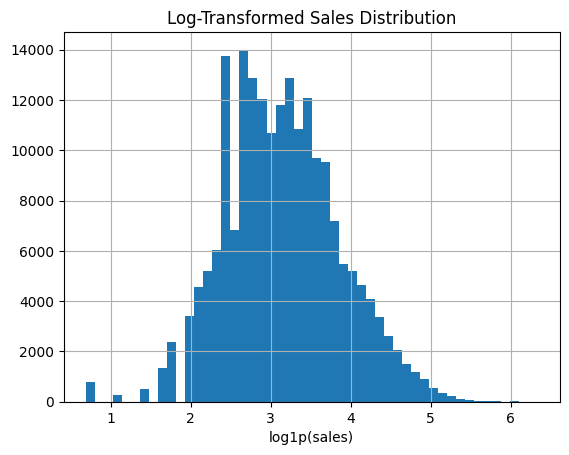

In [17]:
# Log-transformed histogram
np.log1p(df_sales_filled["sales"]).hist(bins=50)
plt.xlabel("log1p(sales)")
plt.title("Log-Transformed Sales Distribution")
plt.show()

Outlier might be valid extreme data point due to seasonality patterns because log-transformed his appeared t0 be continous and natural. 

### Correct Outliers

In [18]:
# Correct outliers by mean
df_sales_corrected = correct_outliers(df_sales_filled)

In [19]:
summary = (
    df_sales_corrected[["store_id", "item_id", "sales"]]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999])
    .iloc[1:]
)
display(summary)

,store_id,item_id,sales
mean,5.392727,17.694545,27.078039
std,2.889226,10.152023,19.609512
min,1.000000,1.000000,1.000000
10%,1.000000,4.000000,9.000000
25%,3.000000,9.000000,13.000000
50%,5.000000,18.000000,21.000000
75%,8.000000,27.000000,34.000000
90%,9.000000,32.000000,54.000000
99%,10.000000,35.000000,96.000000
99.9%,10.000000,35.000000,107.000000


## Weather Data

Rename the `city` column to `province` so the `df_weather` matching to `df_sales`

In [20]:
df_weather=df_weather.rename(columns={"city":"province"})

In [21]:
df_weather.head()

,province,date,temperature,humidity,season
0,Hanoi,2016-01-01,13.4,87.8,winter
1,Ho Chi Minh City,2016-01-01,27.7,69.1,dry
2,Hanoi,2016-01-02,15.2,75.2,winter
3,Ho Chi Minh City,2016-01-02,26.6,69.9,dry
4,Hanoi,2016-01-03,19.2,86.0,winter


### Lookup table

Create lookup table for mapping weather data to sale data

In [22]:
df_weather.loc[2, ["temperature","humidity","season"]]

temperature      15.2
humidity         75.2
season         winter
Name: 2, dtype: object

In [23]:
weather_mapping=df_weather.set_index(["date", "province"])
weather_mapping.head()

temperature  humidity  season
date       province                                       
2016-01-01 Hanoi                    13.4      87.8  winter
           Ho Chi Minh City         27.7      69.1     dry
2016-01-02 Hanoi                    15.2      75.2  winter
           Ho Chi Minh City         26.6      69.9     dry
2016-01-03 Hanoi                    19.2      86.0  winter

In [28]:
weather_mapping.loc[("2016-01-01", "Ho Chi Minh City"),"season"]

'dry'

## Save the preprocessed data

In [25]:
sale_data_path=os.path.join(DATA_DIR, "sales_data.csv")
print("Saving cleaned sales data to: {}".format(sale_data_path))
df_sales_corrected.to_csv(sale_data_path, index=False)

weather_mapping_path=os.path.join(DATA_DIR, "weather_mapping.csv")
print("Saving weather mapping to: {}".format(weather_mapping_path))
weather_mapping.to_csv(weather_mapping_path)

Saving cleaned sales data to: ../data/sales_data.csv
Saving weather mapping to: ../data/weather_mapping.csv
